<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
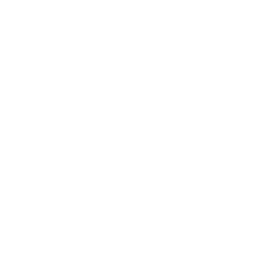
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Medication Error Rate EWMA Trend Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Healthcare / Patient Safety &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Esta análise monitora a taxa semanal de erros de medicação em uma unidade de terapia intensiva (UTI) hospitalar usando um **gráfico de controle de média móvel ponderada exponencialmente (EWMA)** do PROC MACONTROL. A UTI implantou um novo sistema eletrônico de registro de administração de medicamentos (eMAR) na semana 51 da janela de observação. As equipes de segurança do paciente precisam de um método de alerta precoce que sinalize um aumento sustentado nos erros rapidamente, antes que um trimestre de relatos de dano se acumule.

O gráfico EWMA com peso de suavização **lambda = 0,3** é construído em duas fases. Os limites de controle são estabelecidos primeiro a partir da linha de base estável pré-migração (semanas 1-50) e, em seguida, a série completa de 100 semanas é monitorada contra esses limites fixos. O gráfico permanece sob controle durante toda a linha de base e sinaliza uma condição fora de controle na **primeira semana após a entrada em produção**, confirmando que a transição do eMAR coincidiu com uma mudança real e sustentada na taxa de erros, e não com ruído semanal comum.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Taxa semanal de erros de medicação por 1.000 administrações para uma UTI, 100 semanas consecutivas | 100 |

Uma única UTI é acompanhada semanalmente. Cada registro contém o número da semana, a taxa de erro por 1.000 administrações, o volume de administrações e a contagem de erros derivada. Uma mudança de processo documentada (entrada em produção do eMAR) ocorre na semana 51, deslocando a média subjacente da taxa de erro para cima em aproximadamente 1,6 por 1.000.

---

In [1]:
/* --------------------------------------------------------
   Gerar dados semanais de erros de medicação da UTI
   100 semanas consecutivas para uma UTI.
   Um novo sistema eMAR entra em produção na semana 51,
   elevando a média subjacente da taxa de erro de ~3,5 para ~5,1 por 1.000.
   -------------------------------------------------------- */
dados work.icu_errors;
    chamar streaminit(42);
    comprimento unit_name $12 phase $12;
    unit_name = 'UTI';
    base_rate  = 3.5;   /* média pré-migração / 1.000 */
    unit_sigma = 0.45;  /* ruído semanal de causa comum */
    fazer week_num = 1 até 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        se administrations < 300 então administrations = 300;
        /* migração do eMAR desloca a média para cima após a semana 50 */
        se week_num > 50 então fazer;
            phase = 'PÓS-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        fim;
        senão fazer;
            phase = 'BASAL';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        fim;
        se error_rate_per_1k < 0 então error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        saída;
    fim;
    remover base_rate unit_sigma;
    formato week_start_date date9.;
executar;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                        Taxa de Erros na UTI: Basal vs. Pós-eMAR                                        

                                                  The MEANS Procedure

                             Analysis Variable : error_rate_per_1k Taxa de Erros por 1.000

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        BASAL                 50           3.50           0.48           2.55           4.71
        PÓS-eMAR              50           5.11           0.44           3.69           5.96
        ------------------------------------------------------------------------------------

                                   Analysis Variable : error_count Contagem de Erros

        Fase               N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


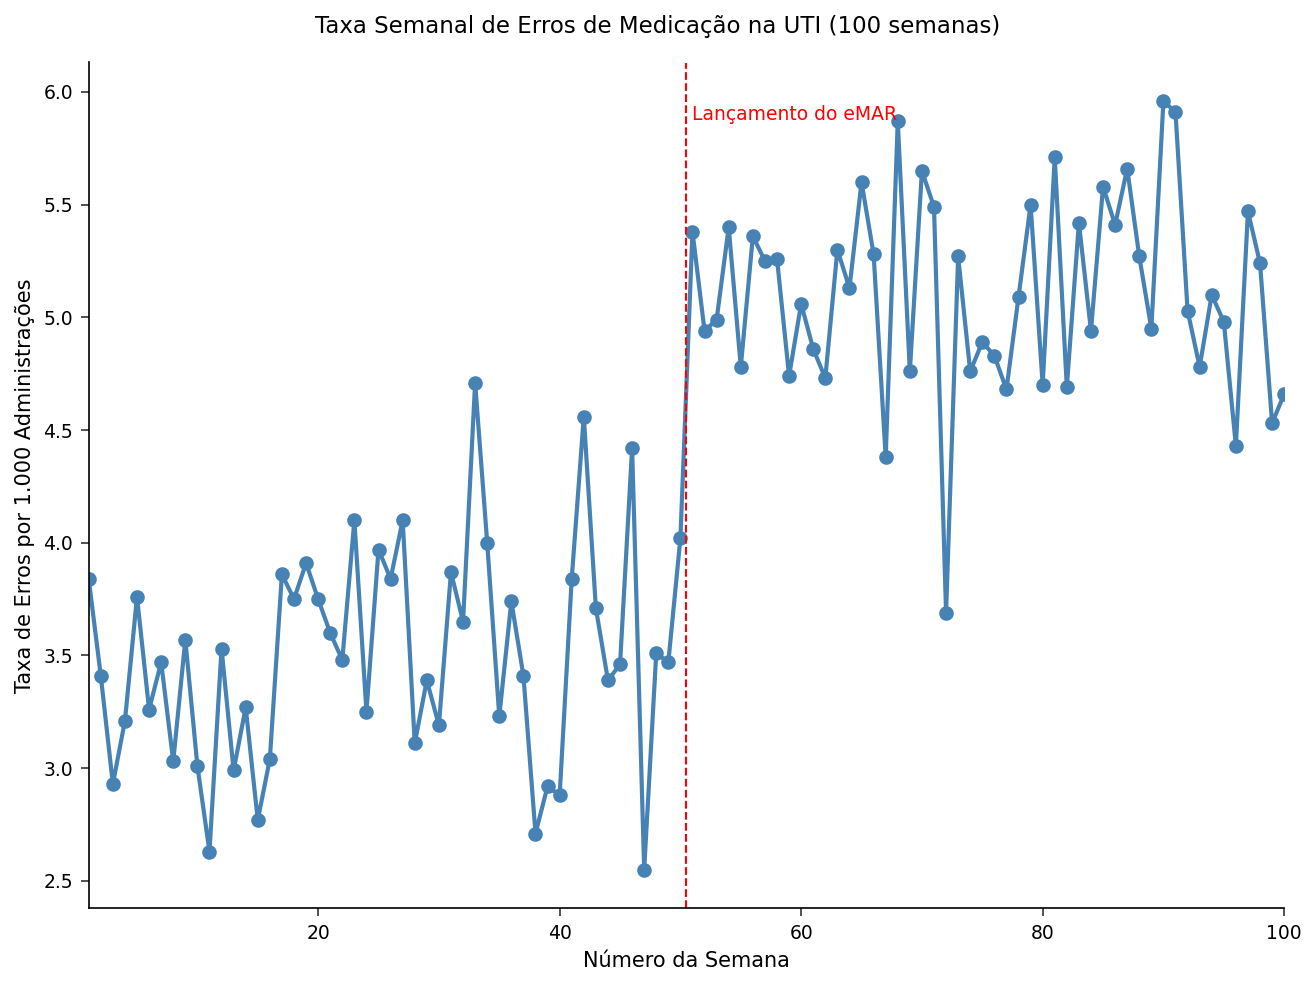

In [2]:
/* --------------------------------------------------------
   Comparar a taxa de erro antes e depois da entrada em
   produção do eMAR, e plotar a tendência semanal.
   -------------------------------------------------------- */
procedimento médias dados=work.icu_errors n mean std min max maxdec=2;
    classe phase;
    variável error_rate_per_1k error_count administrations;
    rótulo phase="Fase" error_rate_per_1k="Taxa de Erros por 1.000"
          error_count="Contagem de Erros" administrations="Administrações";
    título "Taxa de Erros na UTI: Basal vs. Pós-eMAR";
executar;

procedimento sgplot dados=work.icu_errors;
    series x=week_num y=error_rate_per_1k / markers
           lineattrs=(color=steelblue thickness=2);
    refline 50.5 / axis=x lineattrs=(color=red pattern=dash)
                   label='Lançamento do eMAR';
    xaxis label='Número da Semana';
    yaxis label='Taxa de Erros por 1.000 Administrações';
    título "Taxa Semanal de Erros de Medicação na UTI (100 semanas)";
executar;

---

In [3]:
/* --------------------------------------------------------
   Fase I: estabelecer os limites de controle EWMA a partir
   da linha de base estável pré-migração (semanas 1-50). Esses
   limites fixos se tornam a referência para todo o período
   de monitoramento.
   -------------------------------------------------------- */
procedimento médias dados=work.icu_errors(where=(week_num <= 50)) noprint;
    variável error_rate_per_1k;
    output out=work.baseline_stats mean=base_mean std=base_std;
executar;

dados work.icu_limits;
    definir work.baseline_stats;
    comprimento _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* linha central da linha de base */
    _STDDEV_ = base_std;    /* sigma de causa comum da linha de base */
    _LIMITN_ = 1;
    manter _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
executar;

procedimento imprimir dados=work.icu_limits noobs;
    título "Insumos de Limites de Controle - Fase I (semanas basais 1-50)";
executar;

                             Insumos de Limites de Controle - Fase I (semanas basais 1-50)                              

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                             Insumos de Limites de Controle - Fase I (semanas basais 1-50)                              


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/4c2151f4-be77-4115-b82e-6c8e4d588735/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


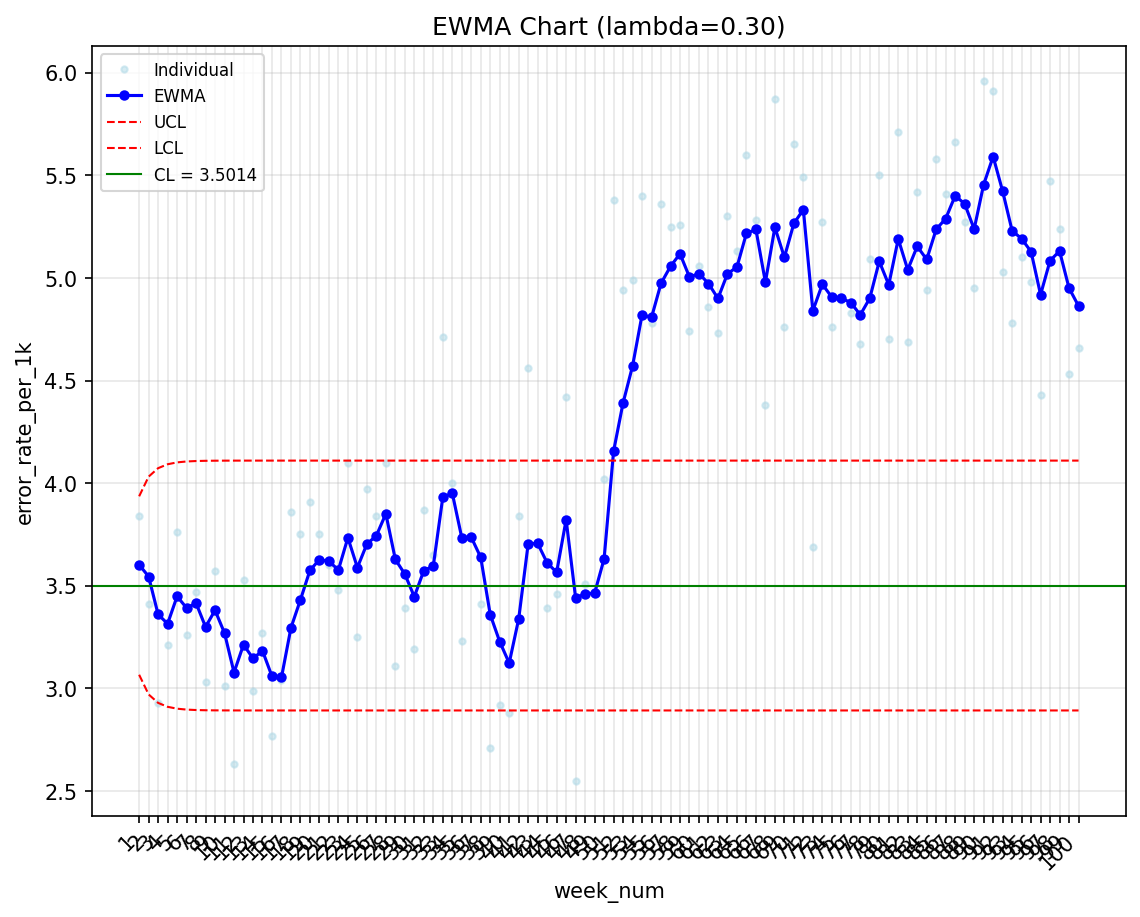

In [4]:
/* --------------------------------------------------------
   Fase II: monitorar a série completa de 100 semanas contra
   os limites fixos da linha de base. lambda=0,3 fornece
   detecção responsiva apropriada para vigilância de segurança
   do paciente.
   -------------------------------------------------------- */
procedimento macontrol dados=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        weight    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    rótulo error_rate_per_1k =
          "Erros de Medicação por 1.000 Administrações";
    título "Gráfico EWMA: Taxa de Erros de Medicação na UTI (lambda=0,3)";
executar;

---

In [5]:
/* --------------------------------------------------------
   Identificar toda semana cujo EWMA rompe os limites da
   linha de base e informar quando o gráfico sinaliza pela
   primeira vez.
   -------------------------------------------------------- */
dados work.signals;
    definir work.icu_table;
    onde _EXLIM_ ne ' ' e_lógico _EXLIM_ ne '0';
executar;

procedimento sql;
    selecionar count(*)        as n_signals          rótulo='Semanas de Sinal',
           min(week_num)    as first_signal_week  rótulo='Primeira Semana de Sinal',
           max(_EWMA_)      as peak_ewma formato=6.3 rótulo='Pico do EWMA'
    de_tabela work.signals;
quit;

procedimento imprimir dados=work.signals(obs=8);
    variável week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    título "Primeiros Sinais de Fora de Controle do EWMA";
executar;

                             Insumos de Limites de Controle - Fase I (semanas basais 1-50)                              

Semanas de Sinal  Primeira Semana de Sinal  Pico do EWMA
----------------  ------------------------  ------------
              50                      51.0         5.591
                                      Primeiros Sinais de Fora de Controle do EWMA                                      

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interpretação

A análise EWMA em duas fases separa claramente a variação semanal comum da mudança real de processo na entrada em produção do eMAR.

**Linha de base (semanas 1-50).** O PROC MEANS informa uma taxa de erro média basal de **3,50 por 1.000 administrações** (desvio padrão 0,48), contra uma média pós-migração de **5,11** (desvio padrão 0,44) — uma mudança ascendente sustentada de cerca de **1,6 erros por 1.000**. O volume de administrações é comparável entre as duas fases (795 vs. 790 por semana), portanto a mudança reflete a *taxa* de erro, e não uma oscilação na carga de trabalho.

**Limites de controle.** Os limites são fixados apenas a partir da linha de base: linha central **3,5014**, sigma da linha de base **0,4829**. Com peso de suavização lambda = 0,3 e limites de 3 sigmas, o limite superior do EWMA se estabiliza em seu valor assintótico de cerca de **4,11**. Ao longo das semanas 1-50, a estatística EWMA permanece dentro desses limites — a linha de base produz **zero falsos alarmes**, confirmando que o gráfico não é excessivamente sensível.

**Detecção.** O gráfico sinaliza fora de controle na **primeiríssima semana após a entrada em produção (semana 51)**, quando o EWMA atinge **4,156**, pouco acima do limite de 4,11. A partir desse ponto, a estatística sobe continuamente e permanece acima do limite superior durante todo o período pós-migração: **todas as 50 semanas pós-migração (51-100) sinalizam**, e o EWMA atinge o pico de **5,591** por volta da semana 91. A responsividade de lambda = 0,3 significa que a deterioração é sinalizada imediatamente, em vez de após várias semanas de acúmulo.

**Ação.** Uma ruptura sustentada do EWMA que começa na semana de uma implantação do eMAR é forte evidência de que o novo sistema — e não o acaso — impulsionou o aumento. O comitê de segurança do paciente deve tratar a semana 51 como o ponto de mudança, auditar os fluxos de trabalho de prescrição e substituição (override) do eMAR introduzidos naquela semana, e manter o gráfico em execução contra os limites originais da linha de base até que o EWMA volte a ficar abaixo de 4,11. Os arquivos exportados `icu_ewma_signals.csv` (50 semanas de sinal) e `icu_ewma_table.csv` fornecem a trilha de evidências de SPC documentada para a revisão de prontidão contínua da Joint Commission.

---

In [6]:
/* --------------------------------------------------------
   Exportar a tabela EWMA e a lista de sinais para a
   documentação de prontidão contínua da Joint Commission.
   -------------------------------------------------------- */
procedimento export dados=work.icu_table
    outfile='icu_ewma_table.csv'
    dbms=csv replace;
executar;

procedimento export dados=work.signals
    outfile='icu_ewma_signals.csv'
    dbms=csv replace;
executar;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>